In [2]:
import os, json, pickle, warnings, datetime as dt
import numpy as np, pandas as pd, yfinance as yf, torch
from ts2vec import TS2Vec
from sklearn.cluster import KMeans
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings("ignore")
from pathlib import Path  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [3]:
print(torch.__version__)
print(torch.cuda.is_available())

2.7.1+cu118
True


 Config – edit here only

In [4]:
TICKERS   = ["AAPL","MSFT","GOOG","AMZN","TSLA",
             "NVDA","META","JPM","V","BRK-B"]  # 10 for speed
TRAIN_BEG = "2000-01-01"
TRAIN_END = "2020-12-31"
TEST_BEG  = "2021-01-01"
TEST_END  = "2024-12-31"

LOOKBACK  = 256      # window length (bars)
STRIDE    = 1       # step size
EMB_DIM   = 512     # TS2Vec output size
N_EPOCHS  = 20      # keep small for today
N_CLUST   = 8       # K-Means clusters
CACHE_DIR = "data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

2️⃣ Download & cache daily OHLCV

In [5]:
def get_ticker_df(tkr, cache_dir="data_cache", start="2010-01-01"):
    f = Path(cache_dir) / f"{tkr}.csv"
    if f.exists():
        return pd.read_csv(f, index_col=0, parse_dates=True)
    df = yf.download(tkr, start=start, progress=False)
    df.to_csv(f)
    return df


# Then build dfs:
dfs = {t: get_ticker_df(t) for t in tqdm(TICKERS)}
print("Downloaded:", len(dfs), "tickers")

100%|██████████| 10/10 [00:08<00:00,  1.19it/s]

Downloaded: 10 tickers


3️⃣ Train/Test split without leakage

In [6]:
from datetime import timedelta

def split_df(df, train_beg, train_end, test_beg, test_end, lookback):
    """Return (train_df, test_df) with a safety gap = lookback-1 bars."""
    # Raw calendar cuts
    train = df.loc[train_beg:train_end].copy()
    test  = df.loc[test_beg:test_end].copy()

    # Drop the last `lookback-1` rows of the train set so that
    # a window of length `lookback` cannot cross into the test period.
    cutoff = pd.to_datetime(train_end) - timedelta(days=lookback - 1)
    train  = train.loc[:cutoff]

    return train, test

train_dfs, test_dfs = {}, {}
for tkr, df in dfs.items():
    tr, te = split_df(df,
                      TRAIN_BEG, TRAIN_END,
                      TEST_BEG , TEST_END,
                      LOOKBACK)
    if len(tr) >= LOOKBACK and len(te) >= LOOKBACK:
        train_dfs[tkr] = tr
        test_dfs[tkr]  = te

print(f"✅  Train rows: {sum(len(x) for x in train_dfs.values()):,}"
      f"  |  Test rows: {sum(len(x) for x in test_dfs.values()):,}"
      f"  across {len(train_dfs)} tickers")

✅  Train rows: 25,189  |  Test rows: 10,050  across 10 tickers


# --- 4️⃣ Build sliding windows -----------------------------------------------

In [7]:

import numpy as np

def make_windows(arr, length, stride):
    """
    Return an array of shape [n_windows, length], guaranteed 2D,
    even if `arr` was accidentally 2D.
    """
    flat = arr.ravel()  # ensure 1-D view
    n = (len(flat) - length) // stride + 1
    return np.stack([flat[i*stride : i*stride + length]
                     for i in range(n)], axis=0)

def windows_from_dict(dfs_dict, length, stride):
    all_wins, meta = [], []
    for ticker, df in dfs_dict.items():
        closes = df["Close"].values.astype("float32")
        wins   = make_windows(closes, length, stride)
        all_wins.append(wins)
        meta.extend([(ticker, i) for i in range(wins.shape[0])])
    return np.vstack(all_wins), meta

train_X, train_meta = windows_from_dict(train_dfs, LOOKBACK, STRIDE)
test_X , test_meta  = windows_from_dict(test_dfs , LOOKBACK, STRIDE)

mu_tr       = train_X.mean(axis=1, keepdims=True)
sigma_tr    = train_X.std(axis=1, keepdims=True)
train_X_rel = (train_X - mu_tr) / sigma_tr
#
mu_te       = test_X.mean(axis=1, keepdims=True)
sigma_te    = test_X.std(axis=1, keepdims=True)
test_X_rel  = (test_X  - mu_te) / sigma_te

print(f"Train windows: {train_X.shape}  |  Test windows: {test_X.shape}")

Train windows: (22639, 256)  |  Test windows: (7500, 256)


# --- 5️⃣ Train mini-TS2Vec ----------------------------------------------------

In [8]:

# --- 5️⃣ Train mini-TS2Vec (fixed input type) -----------------------------
# Prepare train windows as a numpy array [N_windows, length, 1]

print(DEVICE)
train_data = train_X_rel[:, :, None]  # shape (N, LOOKBACK, 1)

# Instantiate the model
model = TS2Vec(input_dims=1, output_dims=EMB_DIM, device=DEVICE)

# Train for N_EPOCHS epochs (you'll see a tqdm progress bar)
model.fit(train_data, n_epochs=N_EPOCHS, verbose=True)

cuda
Epoch #0: loss=1.0801861818136893
Epoch #1: loss=0.5661233719411969
Epoch #2: loss=0.540971195470157
Epoch #3: loss=0.4436106011798392
Epoch #4: loss=0.41819298575082964
Epoch #5: loss=0.4371112826605666
Epoch #6: loss=0.3815618957454784
Epoch #7: loss=0.37595768275511315
Epoch #8: loss=0.35975890806869537
Epoch #9: loss=0.356406379464745
Epoch #10: loss=0.3680306664039677
Epoch #11: loss=0.3702803348919543
Epoch #12: loss=0.33009408617753117
Epoch #13: loss=0.3328307757188357
Epoch #14: loss=0.33529952326012297
Epoch #15: loss=0.3235366857667286
Epoch #16: loss=0.3213893948900059
Epoch #17: loss=0.2961469257442752
Epoch #18: loss=0.3020795431868022
Epoch #19: loss=0.2886108348549171


[1.0801861818136893,
 0.5661233719411969,
 0.540971195470157,
 0.4436106011798392,
 0.41819298575082964,
 0.4371112826605666,
 0.3815618957454784,
 0.37595768275511315,
 0.35975890806869537,
 0.356406379464745,
 0.3680306664039677,
 0.3702803348919543,
 0.33009408617753117,
 0.3328307757188357,
 0.33529952326012297,
 0.3235366857667286,
 0.3213893948900059,
 0.2961469257442752,
 0.3020795431868022,
 0.2886108348549171]

# --- 6️⃣ Embed & Cluster -----------------------------------------------------

In [9]:
import numpy as np
import torch
from sklearn.cluster import KMeans

# 1) Prepare test windows as float32 NumPy [N, LOOKBACK, 1]
test_np = np.asarray(test_X_rel[:, :, None], dtype=np.float32)

# 2) Encode via TS2Vec (may return 3D)
emb = model.encode(test_np)

# 3) If it's a torch tensor, convert to NumPy
if hasattr(emb, "detach"):
    emb = emb.detach().cpu().numpy()

# 4) emb now is either shape (N, LOOKBACK, EMB_DIM) or (N, EMB_DIM)
if emb.ndim == 3:
    # Option A: take the last time-step as the window embedding
    emb_2d = emb[:, -1, :]
    # —or— Option B: average across time:
    # emb_2d = emb.mean(axis=1)
else:
    emb_2d = emb

emb_test = emb_2d   
# 5) Cluster the 2D embeddings
kmeans = KMeans(n_clusters=N_CLUST, random_state=42)
labels = kmeans.fit_predict(emb_2d)

# 6) Sanity-check counts
unique, counts = np.unique(labels, return_counts=True)
print("Cluster counts:", dict(zip(unique, counts)))

Cluster counts: {np.int32(0): np.int64(1198), np.int32(1): np.int64(818), np.int32(2): np.int64(1002), np.int32(3): np.int64(702), np.int32(4): np.int64(1246), np.int32(5): np.int64(973), np.int32(6): np.int64(792), np.int32(7): np.int64(769)}


# --- 7️⃣ Quick-Look Plot: cluster markers on price chart --------------------

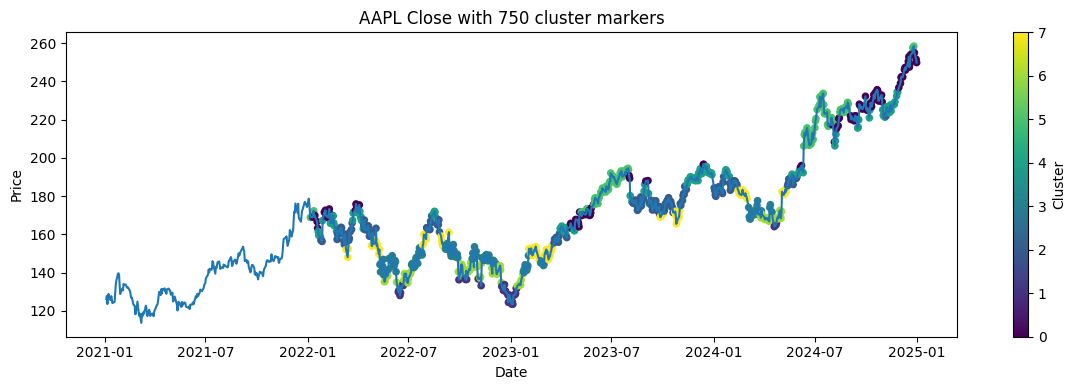

In [10]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt

def plot_ticker_clusters_mpl(tkr):
    df = test_dfs[tkr]
    # compute window‐end points exactly as before
    win_idxs = [i for i,(tk,_) in enumerate(test_meta) if tk==tkr]
    ends     = [test_meta[i][1] + LOOKBACK - 1 for i in win_idxs]
    times    = df.index[ends]
    prices   = df["Close"].iloc[ends]
    colors   = [int(labels[i]) for i in win_idxs]

    plt.figure(figsize=(12,4))
    plt.plot(df.index, df["Close"], label=tkr)
    sc = plt.scatter(times, prices, c=colors, cmap="viridis", s=20)
    plt.colorbar(sc, label="Cluster")
    plt.title(f"{tkr} Close with {len(times)} cluster markers")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

plot_ticker_clusters_mpl("AAPL")






AAPL: 750 markers — cluster counts Counter({2: 139, 4: 116, 0: 111, 5: 103, 3: 99, 7: 78, 6: 71, 1: 33})


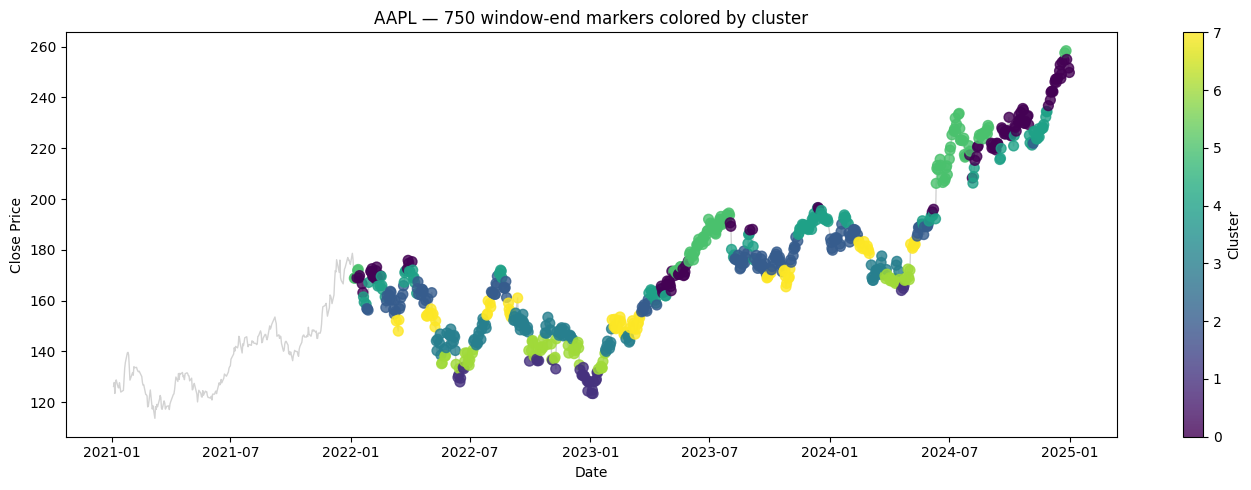

MSFT: 750 markers — cluster counts Counter({0: 144, 2: 116, 4: 108, 7: 98, 6: 83, 3: 69, 1: 68, 5: 64})


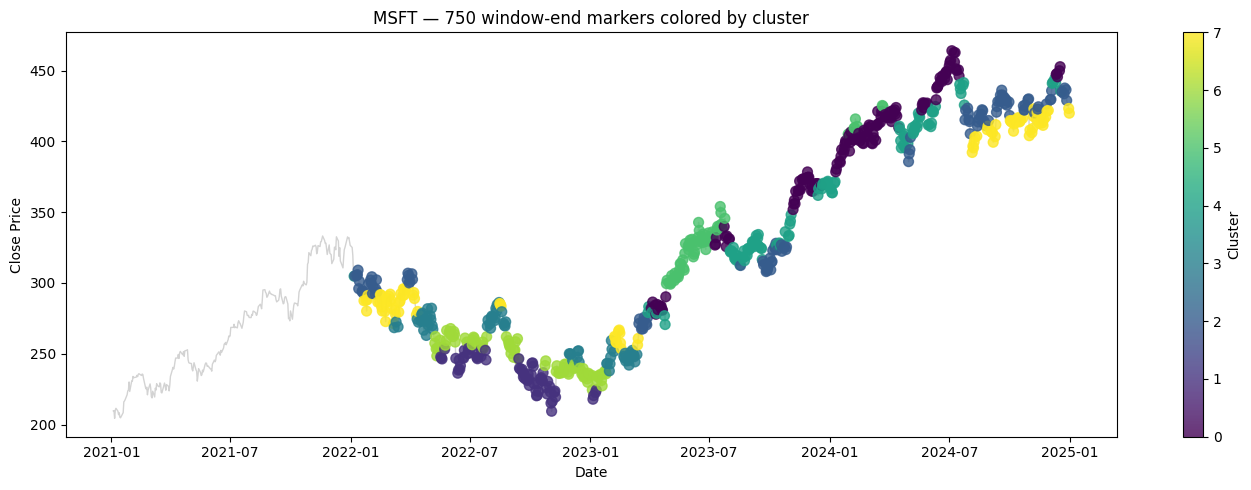

GOOG: 750 markers — cluster counts Counter({1: 134, 0: 121, 2: 118, 4: 102, 7: 84, 6: 75, 5: 75, 3: 41})


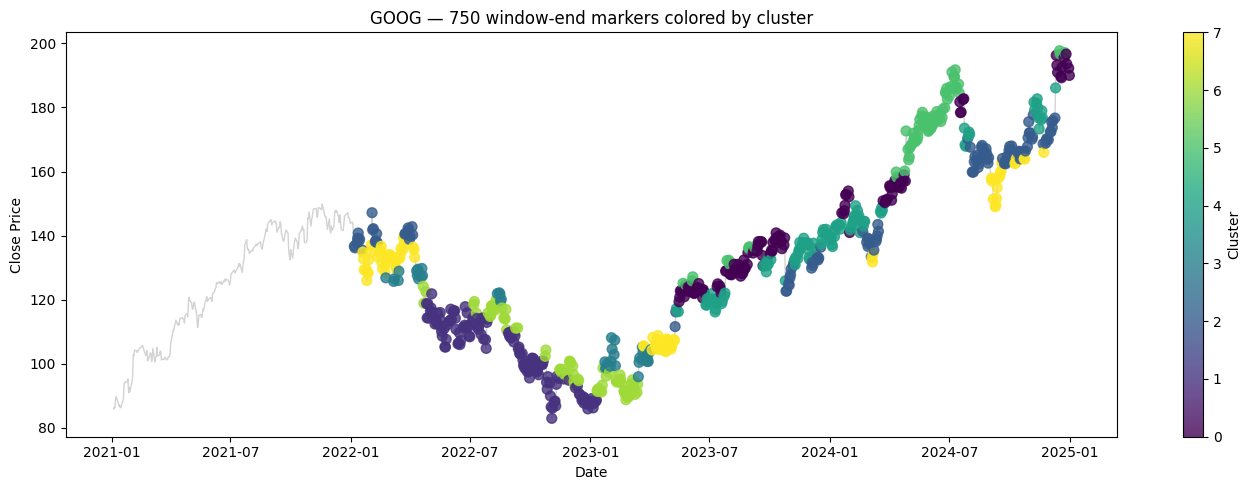

AMZN: 750 markers — cluster counts Counter({0: 159, 1: 138, 4: 102, 6: 97, 3: 95, 2: 84, 5: 44, 7: 31})


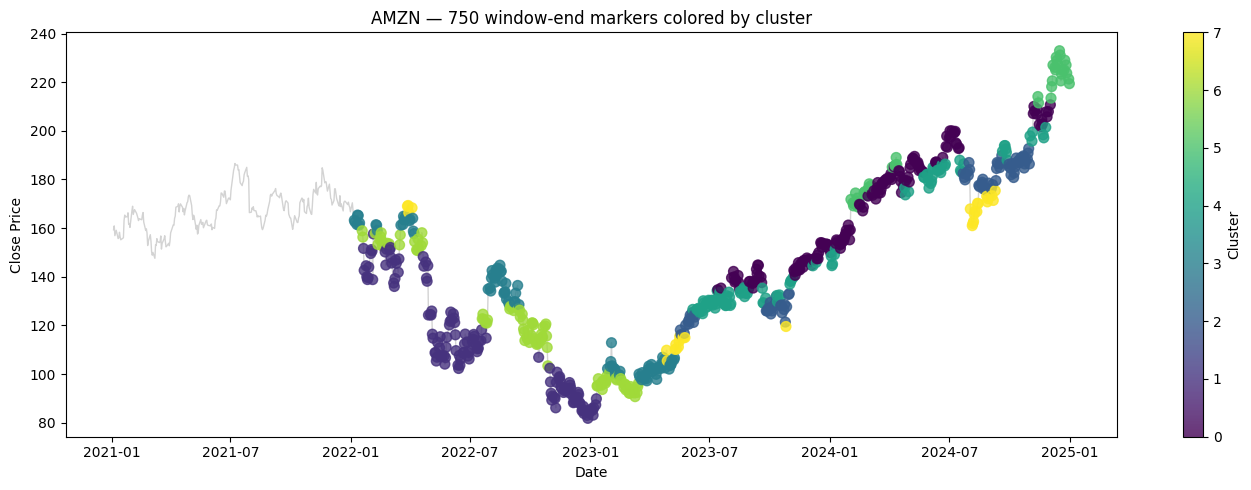

TSLA: 750 markers — cluster counts Counter({7: 141, 6: 141, 2: 136, 3: 132, 1: 90, 4: 55, 5: 38, 0: 17})


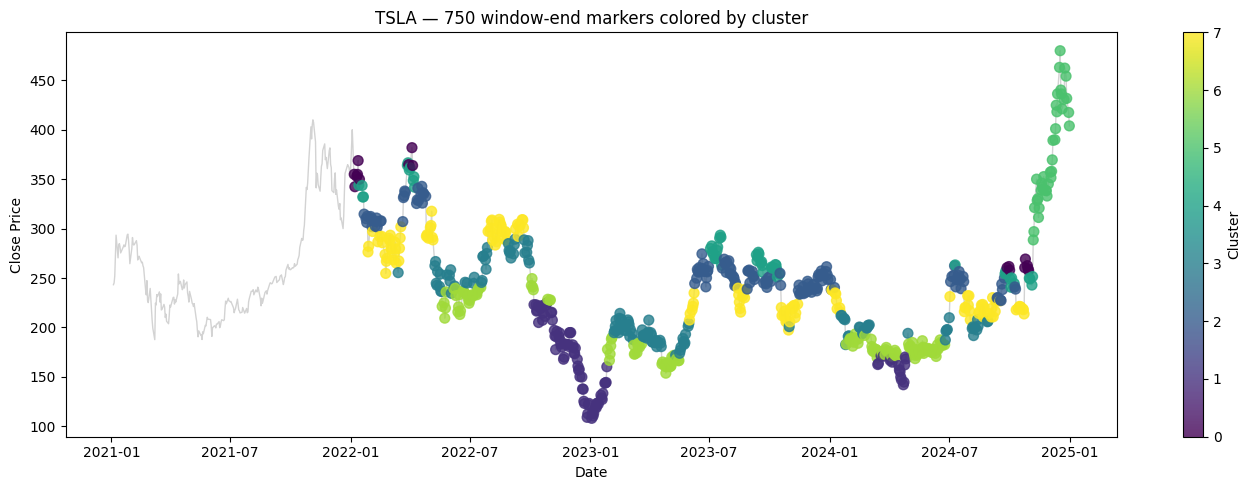

NVDA: 750 markers — cluster counts Counter({5: 184, 4: 150, 0: 111, 2: 77, 6: 68, 3: 64, 1: 61, 7: 35})


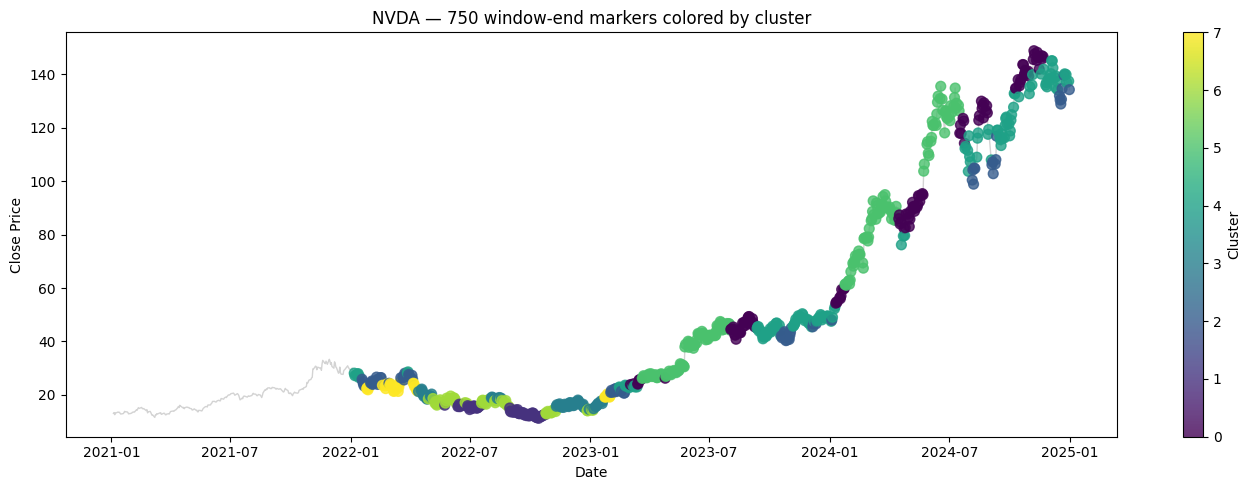

META: 750 markers — cluster counts Counter({4: 206, 1: 123, 6: 109, 5: 105, 0: 103, 2: 49, 3: 28, 7: 27})


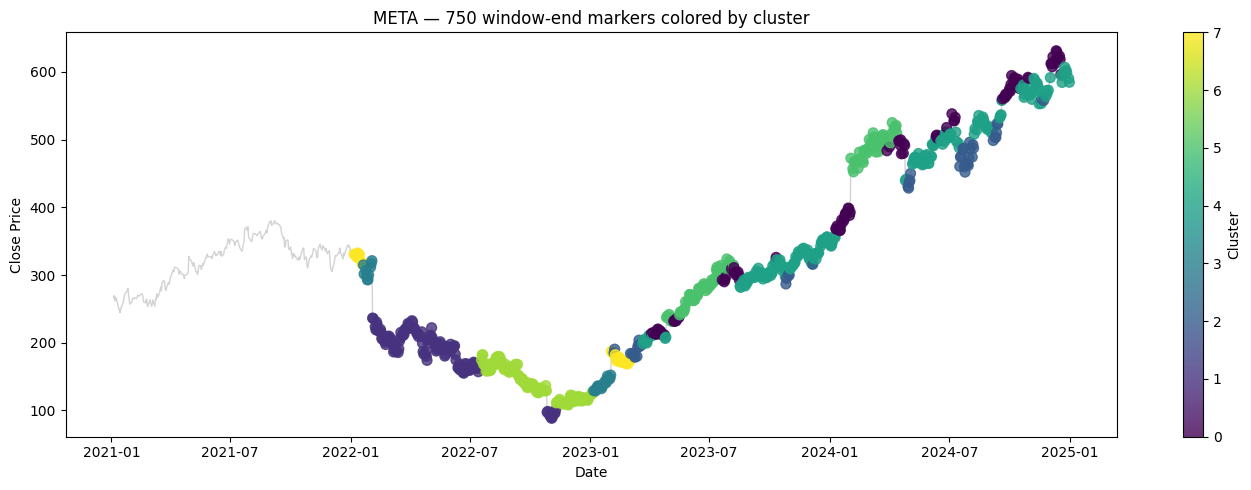

JPM: 750 markers — cluster counts Counter({0: 150, 4: 135, 5: 115, 1: 114, 2: 80, 7: 70, 6: 55, 3: 31})


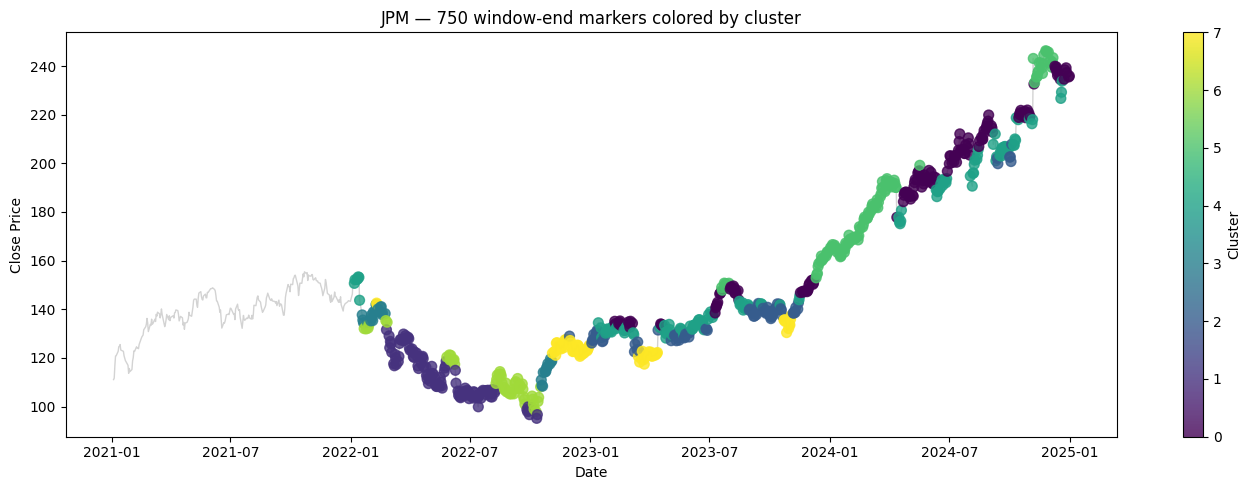

V: 750 markers — cluster counts Counter({2: 133, 4: 125, 5: 117, 7: 97, 0: 94, 3: 85, 1: 53, 6: 46})


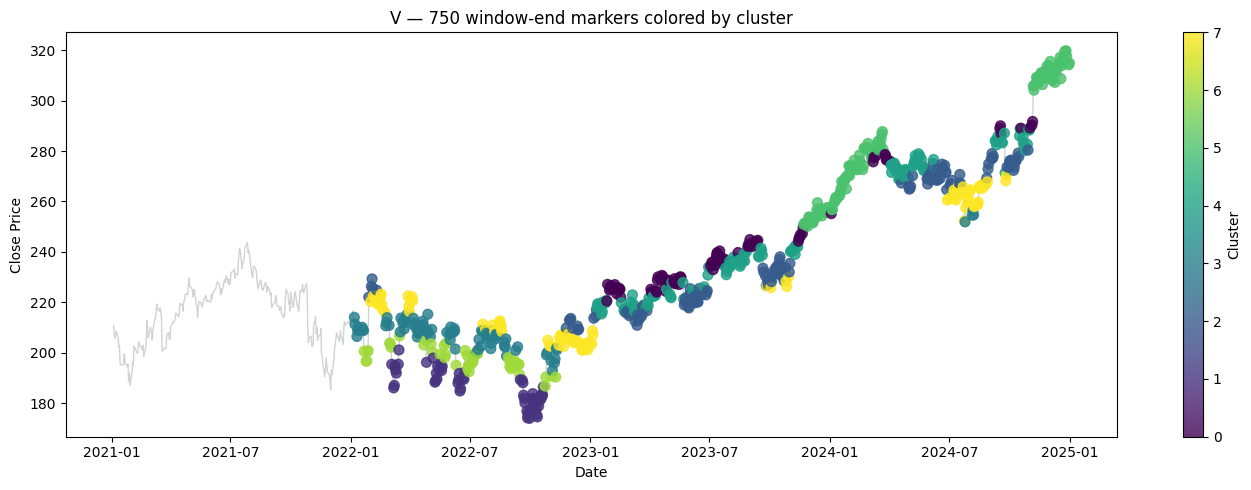

BRK-B: 750 markers — cluster counts Counter({0: 188, 4: 147, 5: 128, 7: 108, 2: 70, 3: 58, 6: 47, 1: 4})


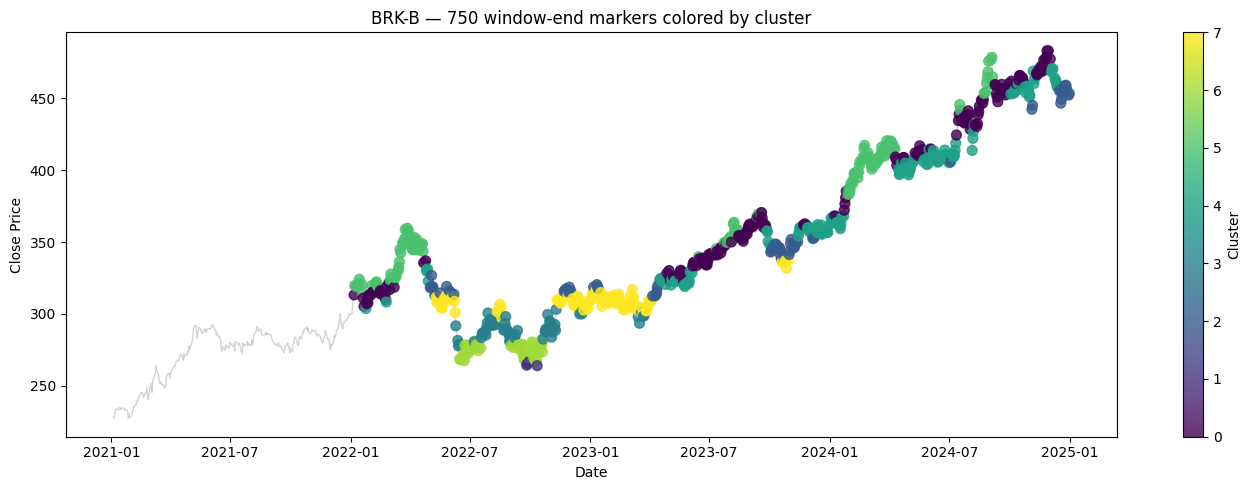

In [11]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_clusters_price_mpl(tkr):
    df = test_dfs[tkr]                      # Close series
    win = [i for i,(tk,_) in enumerate(test_meta) if tk == tkr]
    ends = [test_meta[i][1] + LOOKBACK - 1 for i in win]

    times    = [df.index[e]         for e in ends]
    prices   = [df["Close"].iloc[e] for e in ends]
    clusters = [int(labels[i])       for i in win]

    print(f"{tkr}: {len(times)} markers — cluster counts {Counter(clusters)}")

    # --- PLOT ---------------------------------------------------------------
    plt.figure(figsize=(14,5))
    # 1️⃣ price line   (light gray, behind)
    plt.plot(df.index, df["Close"], linewidth=1, color="lightgray", zorder=1)

    # 2️⃣ scatter of window-ends (colored by cluster, on top)
    sc = plt.scatter(times, prices, c=clusters,
                     cmap="viridis", s=50, alpha=0.8, zorder=2)
    cbar = plt.colorbar(sc, label="Cluster")
    cbar.set_alpha(1)           # make colorbar opaque
    #cbar.draw_all()

    plt.title(f"{tkr} — {len(times)} window-end markers colored by cluster")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.tight_layout()
    plt.show()

for tkr in test_dfs.keys():
    plot_clusters_price_mpl(tkr)

In [12]:
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool, ColorBar, LinearColorMapper, FixedTicker
from bokeh.palettes import Viridis256
import numpy as np
from collections import Counter

output_notebook()

def plot_clusters_bokeh(tkr):
    df = test_dfs[tkr]
    win = [i for i,(tk,_) in enumerate(test_meta) if tk == tkr]
    ends = [test_meta[i][1] + LOOKBACK - 1 for i in win]

    times    = np.array([df.index[e]         for e in ends], dtype="datetime64[ns]")
    prices   = np.array([df["Close"].iloc[e] for e in ends])
    clusters = np.array([int(labels[i])       for i in win])

    print(f"{tkr}: {len(times)} markers — cluster counts {Counter(clusters)}")

    n_clust = clusters.max() + 1
    palette = Viridis256[:: max(1, 256 // n_clust)][:n_clust]
    mapper  = LinearColorMapper(palette=palette, low=0, high=n_clust-1)

    p = figure(height=450, width=900, x_axis_type="datetime",
               title=f"{tkr} – window-end cluster markers")
    p.line(df.index, df["Close"], line_width=1, color="#d3d3d3", legend_label=tkr)

    cds = ColumnDataSource(dict(x=times, y=prices, cluster=clusters))
    p.circle("x", "y", source=cds, size=7,
             fill_color={"field": "cluster", "transform": mapper},
             line_color=None, fill_alpha=0.8, legend_label="Windows")

    p.add_tools(HoverTool(tooltips=[
        ("Date"   , "@x{%F}"),
        ("Close"  , "@y{0.2f}"),
        ("Cluster", "@cluster"),
    ], formatters={"@x": "datetime"}))

    color_bar = ColorBar(color_mapper=mapper, title="Cluster",
                         location=(0, 0),
                         ticker=FixedTicker(ticks=list(range(n_clust))))
    p.add_layout(color_bar, "right")

    p.legend.location = "top_left"
    show(p)

# Example call
plot_clusters_bokeh("AAPL")

Loading BokehJS ...

AAPL: 750 markers — cluster counts Counter({np.int64(2): 139, np.int64(4): 116, np.int64(0): 111, np.int64(5): 103, np.int64(3): 99, np.int64(7): 78, np.int64(6): 71, np.int64(1): 33})


In [13]:
# --- helper: centroid & representative windows -----------------------------
from scipy.spatial.distance import cdist

centroids = kmeans.cluster_centers_            # [k, dim]

# find training window closest to each centroid
repr_idx = cdist(emb_test, centroids).argmin(axis=0)   # 1 idx per cluster
repr_meta = [test_meta[i] for i in repr_idx]

def get_window(meta):
    tkr, start = meta
    series = test_dfs[tkr]["Close"].values
    return series[start : start + LOOKBACK]

repr_windows = [get_window(m) for m in repr_meta]      # list of 1-D arrays

repr_windows_rel = [ test_X_rel[idx] for idx in repr_idx ]

# --- cosine similarity for every test window to every centroid -------------
# emb_test : [N_test, dim]
norm_test   = np.linalg.norm(emb_test,  axis=1, keepdims=True)
norm_cent   = np.linalg.norm(centroids, axis=1, keepdims=True).T
cos_sim     = (emb_test @ centroids.T) / (norm_test * norm_cent)   # [N, k]

# we'll reuse cos_sim later in Bokeh

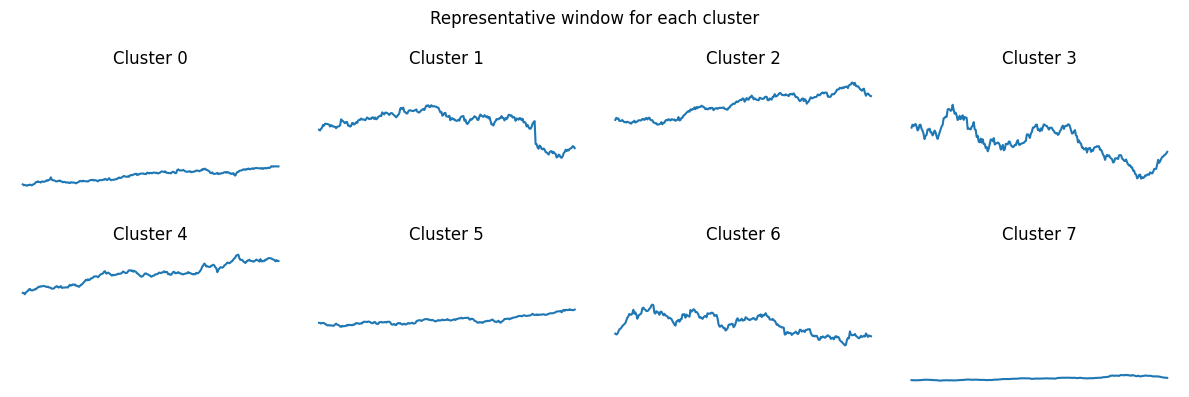

In [14]:
# --- tiny gallery of representative patterns --------------------------------
import matplotlib.pyplot as plt

ncols = 4
nrows = int(np.ceil(N_CLUST / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2*nrows), sharey=True)

for c in range(N_CLUST):
    ax = axes.flatten()[c]
    ax.plot(repr_windows[c], color='tab:blue')
    ax.set_title(f"Cluster {c}")
    ax.axis('off')

plt.suptitle("Representative window for each cluster")
plt.tight_layout()
plt.show()

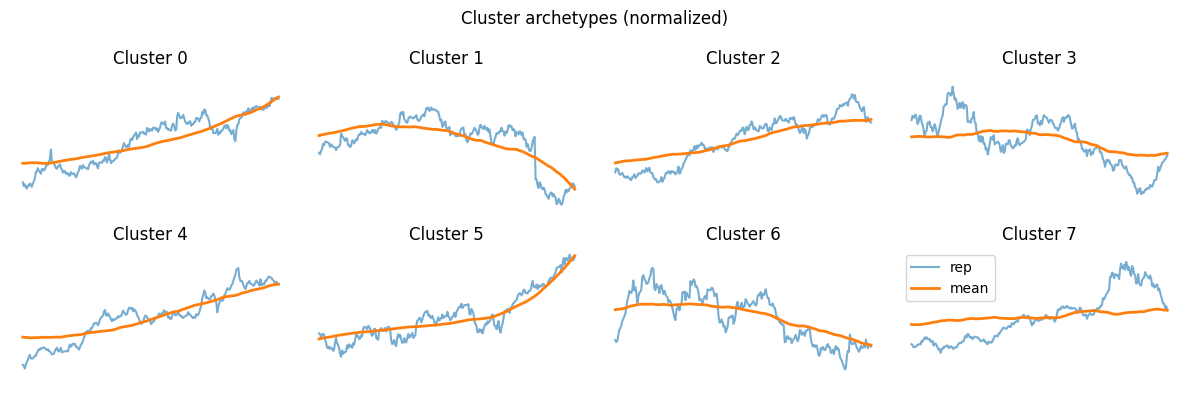

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 1) Re-compute centroids and distances if needed
centroids = kmeans.cluster_centers_                # [k, dim]
dists     = cdist(emb_test, centroids, metric="euclidean")
repr_idx  = dists.argmin(axis=0)                   # index of closest window per cluster

# 2) Build normalized windows (must have run the 4.1 cell already!)
#    test_X_rel is shape [N_test, LOOKBACK]
repr_windows_rel = [ test_X_rel[idx] for idx in repr_idx ]

# 3) (Optional) also compute the average pattern per cluster
avg_patterns = []
for c in range(N_CLUST):
    members = np.where(labels == c)[0]
    avg_patterns.append(test_X_rel[members].mean(axis=0))

# 4) Plot them in a grid
ncols = 4
nrows = int(np.ceil(N_CLUST/ ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2*nrows), sharey=True)

for c in range(N_CLUST):
    ax = axes.flatten()[c]
    # **Here’s where repr_windows_rel goes:**
    ax.plot(repr_windows_rel[c], label="rep",    alpha=0.6)
    ax.plot(avg_patterns[c],       label="mean", lw=2)
    ax.set_title(f"Cluster {c}")
    ax.axis("off")

plt.suptitle("Cluster archetypes (normalized)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
from bokeh.io      import output_notebook, show
from bokeh.plotting import figure
from bokeh.models  import (
    ColumnDataSource, CDSView, BooleanFilter,
    Slider, HoverTool, LinearColorMapper, ColorBar, FixedTicker, CustomJS
)
from bokeh.layouts import column
import numpy as np

output_notebook()  # render inline

# Precompute once (after you define emb_test = normalized embeddings):
# centroids: from your KMeans on emb_test
centroids = kmeans.cluster_centers_         # shape [K, D]
# compute normalized-test embeddings if you haven't already:
# emb_test_rel was built from test_X_rel in Part 6
# precompute sim matrix [N_test, K]:
norm_test = np.linalg.norm(emb_test,   axis=1, keepdims=True)
norm_cent = np.linalg.norm(centroids, axis=1, keepdims=True).T
cos_sim   = (emb_test @ centroids.T) / (norm_test * norm_cent)

def interactive_pattern_overlay(tkr, cluster_id, init_thresh=0.9):
    df    = test_dfs[tkr]
    # find all windows for this ticker
    idxs  = [i for i,(tk,_) in enumerate(test_meta) if tk == tkr]
    ends  = [test_meta[i][1] + LOOKBACK - 1 for i in idxs]
    sims  = cos_sim[idxs, cluster_id]             # similarity for this cluster

    # prepare Bokeh data source
    cds = ColumnDataSource(dict(
        x   = [df.index[e]        for e in ends],
        y   = [df["Close"].iloc[e] for e in ends],
        sim = sims
    ))
    # initial filter
    view = CDSView(filter=BooleanFilter(sims >= init_thresh))

    # build figure
    p = figure(x_axis_type="datetime", height=400, width=900,
               title=f"{tkr}: pattern {cluster_id} detections (sim ≥ {init_thresh})")
    p.line(df.index, df["Close"], color="#d3d3d3", line_width=1)

    mapper = LinearColorMapper(palette="Viridis256", low=0, high=1)
    p.circle("x", "y", source=cds, view=view, size=8,
             fill_color={'field':'sim','transform':mapper},
             fill_alpha=0.8, line_color=None)

    p.add_tools(HoverTool(formatters={'@x':'datetime'},
                          tooltips=[("Date","@x{%F}"),("Close","@y{0.2f}"),("sim","@sim{0.00}")]))
    color_bar = ColorBar(color_mapper=mapper, ticker=FixedTicker(ticks=[0,0.5,1]), title="sim")
    p.add_layout(color_bar, "right")

    # slider to update the filter
    slider = Slider(start=0, end=1, value=init_thresh, step=0.01,
                    title="show sim ≥")
    slider.js_on_change(
        "value",
        CustomJS(args=dict(source=cds, view=view, slider=slider), code="""
            const sims = source.data.sim;
            const thr  = slider.value;
            view.filter.booleans = sims.map(v => v >= thr);
            source.change.emit();
        """)
    )

    show(column(slider, p))

# ─── Example: show cluster 6 matches on AAPL ───────────────────────────
interactive_pattern_overlay("AAPL", cluster_id=7, init_thresh=0.85)


Loading BokehJS ...